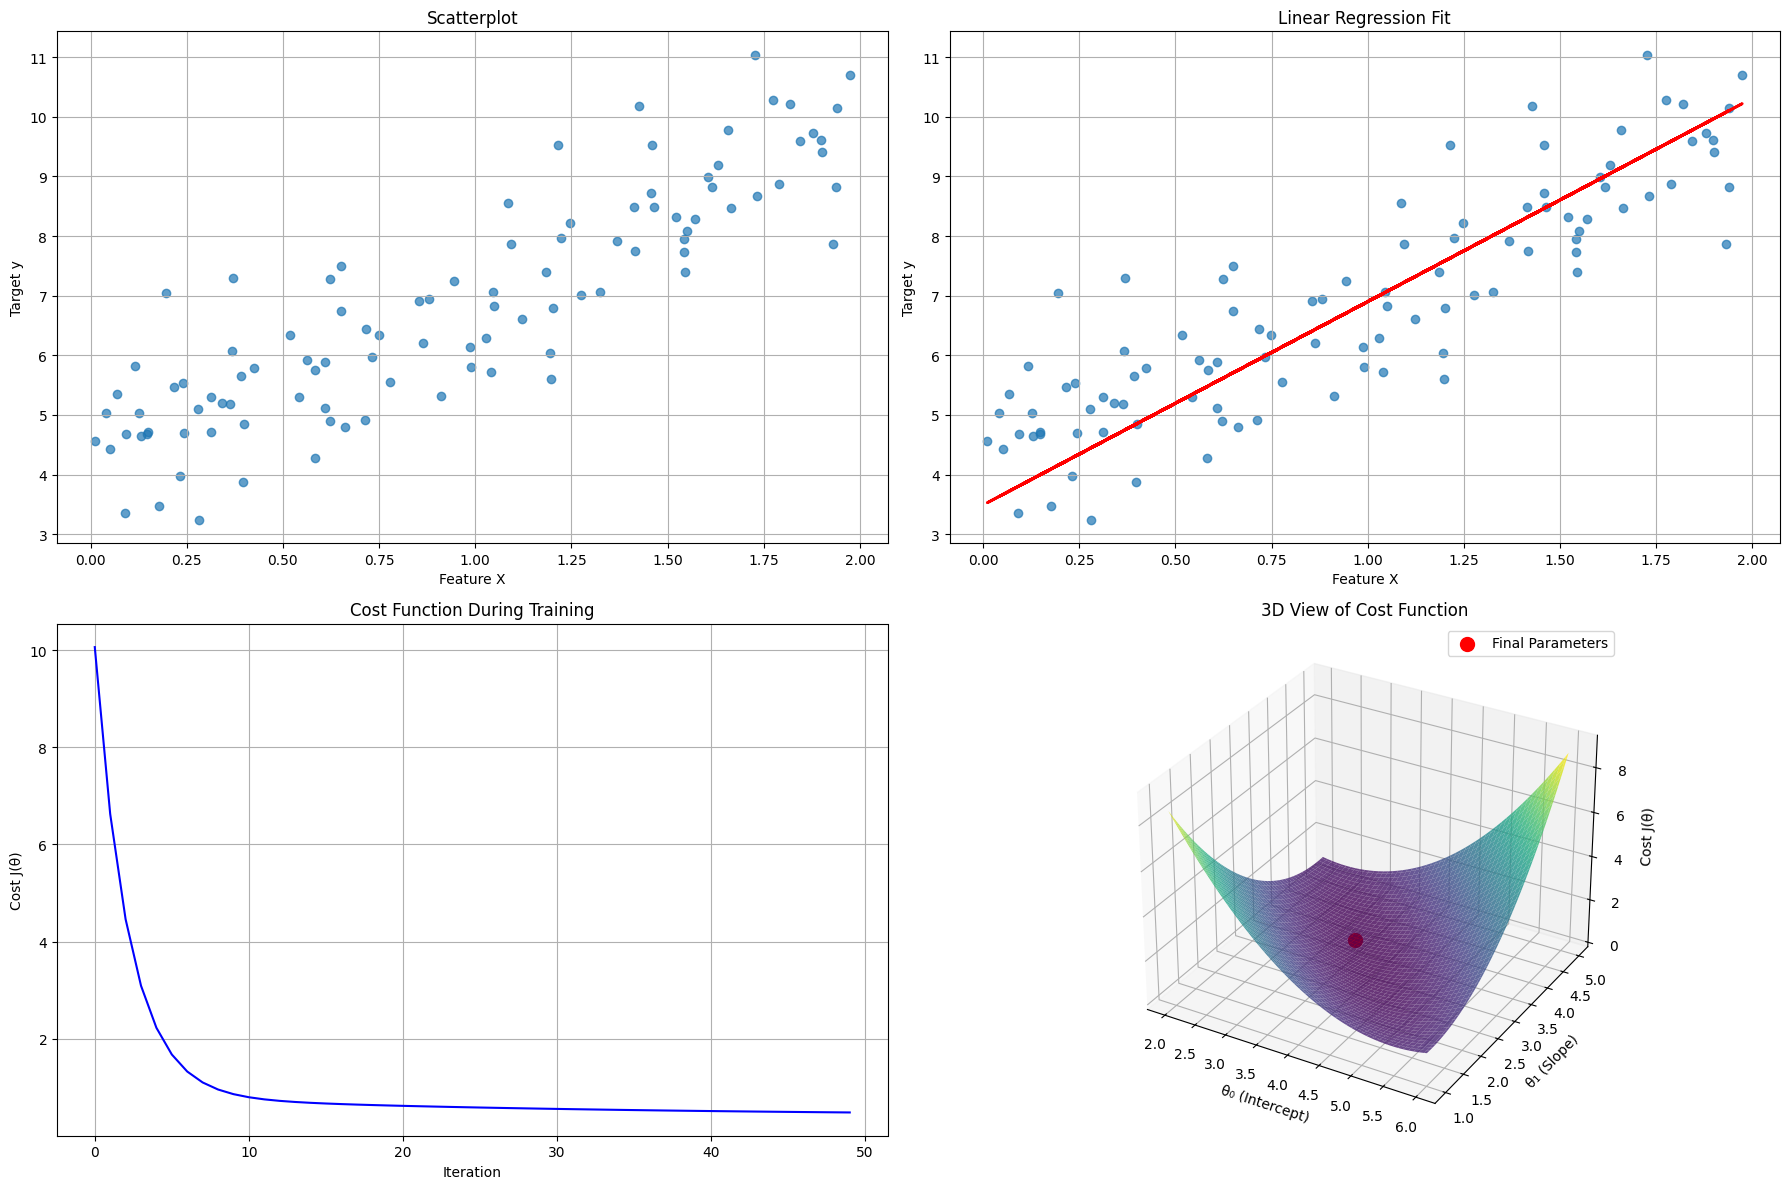

Final parameters: β₀ = 3.4893, β₁ = 3.4109


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

class SimpleLinearRegression:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.theta = None
        self.cost_history = []

    def compute_cost(self, X, y, theta):
        """Compute the mean squared error cost function"""
        m = len(y)
        predictions = X.dot(theta)
        cost = (1/(2*m)) * np.sum((predictions - y)**2)
        return cost

    def gradient_descent(self, X, y, theta):
        """Perform gradient descent to minimize the cost function"""
        m = len(y)
        cost_history = np.zeros(self.iterations)

        for i in range(self.iterations):
            predictions = X.dot(theta)
            errors = predictions - y
            gradient = (1/m) * X.T.dot(errors)
            theta = theta - self.learning_rate * gradient
            cost_history[i] = self.compute_cost(X, y, theta)

        return theta, cost_history

    def fit(self, X, y):
        """Train the linear regression model"""
        # Add bias term (column of ones)
        X_b = np.c_[np.ones((len(X), 1)), X]

        # Initialize parameters
        initial_theta = np.random.randn(2, 1)

        # Run gradient descent
        self.theta, self.cost_history = self.gradient_descent(X_b, y, initial_theta)

    def predict(self, X):
        """Make predictions using the trained model"""
        X_b = np.c_[np.ones((len(X), 1)), X]
        return X_b.dot(self.theta)

# Generate synthetic data
np.random.seed(42)
m = 100
X = 2 * np.random.rand(m, 1)
y = 4 + 3 * X + np.random.randn(m, 1)

# Create and train the model
model = SimpleLinearRegression(learning_rate=0.1, iterations=50)
model.fit(X, y)

# Plotting
plt.figure(figsize=(18, 12))

# 1. Plot the data
plt.subplot(2, 2, 1)
plt.scatter(X, y, alpha=0.7)
plt.title('Scatterplot')
plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.grid(True)

# 1. Plot the data and regression line
plt.subplot(2, 2, 2)
plt.scatter(X, y, alpha=0.7)
plt.plot(X, model.predict(X), 'r-', linewidth=2)
plt.title('Linear Regression Fit')
plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.grid(True)

# 2. Plot the cost function history
plt.subplot(2, 2, 3)
plt.plot(range(model.iterations), model.cost_history, 'b-')
plt.title('Cost Function During Training')
plt.xlabel('Iteration')
plt.ylabel('Cost J(θ)')
plt.grid(True)

# 3. Create 3D plot of the cost function
ax = plt.subplot(2, 2, 4, projection='3d')

# Grid of theta values
theta0 = np.linspace(2, 6, 100)
theta1 = np.linspace(1, 5, 100)
theta0_grid, theta1_grid = np.meshgrid(theta0, theta1)
cost_grid = np.zeros_like(theta0_grid)

X_b = np.c_[np.ones((m, 1)), X]

# Compute cost for each theta combination
for i in range(len(theta0)):
    for j in range(len(theta1)):
        theta = np.array([theta0[i], theta1[j]]).reshape(-1, 1)
        cost_grid[i, j] = model.compute_cost(X_b, y, theta)

# Plot surface
surf = ax.plot_surface(theta0_grid, theta1_grid, cost_grid, cmap='viridis', alpha=0.8)
plt.title('3D View of Cost Function')
ax.set_xlabel('θ₀ (Intercept)')
ax.set_ylabel('θ₁ (Slope)')
ax.set_zlabel('Cost J(θ)')

# Mark the final theta values (FIXED HERE - removed duplicate 's' parameter)
ax.scatter([model.theta[0]], [model.theta[1]], [model.compute_cost(X_b, y, model.theta)],
           color='red', s=100, label='Final Parameters')
ax.legend()

plt.tight_layout()
plt.show()

# Print final parameters
print(f"Final parameters: β₀ = {model.theta[0][0]:.4f}, β₁ = {model.theta[1][0]:.4f}")


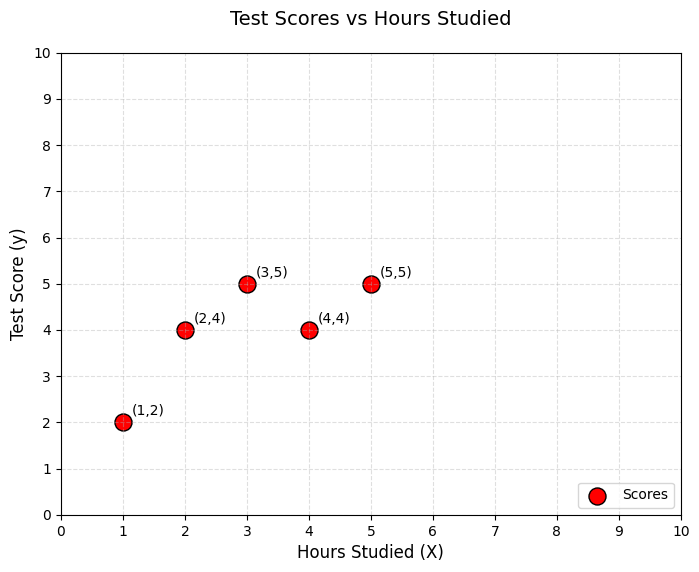

In [ ]:
import matplotlib.pyplot as plt

# Data
hours_studied = [1, 2, 3, 4, 5]
test_scores = [2, 4, 5, 4, 5]

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(hours_studied, test_scores, color='red', s=150, edgecolor='black', label='Scores')

# Set axis limits (0 to 10)
plt.xlim(0, 10)
plt.ylim(0, 10)

# Add labels and title
plt.title('Test Scores vs Hours Studied', fontsize=14, pad=20)
plt.xlabel('Hours Studied (X)', fontsize=12)
plt.ylabel('Test Score (y)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)

# Annotate each point
for i, (x, y) in enumerate(zip(hours_studied, test_scores)):
    plt.annotate(f'({x},{y})', (x+0.15, y+0.15), fontsize=10)

# Customize ticks (show every integer)
plt.xticks(range(0, 11))
plt.yticks(range(0, 11))

# Add legend and show plot
plt.legend(loc='lower right')
plt.show()

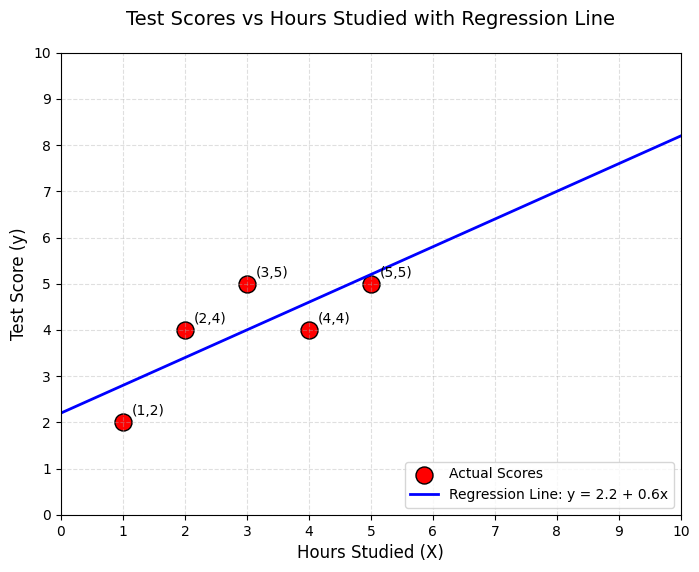

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
hours_studied = [1, 2, 3, 4, 5]
test_scores = [2, 4, 5, 4, 5]

# Regression line: y = 2.2 + 0.6x
def regression_line(x):
    return 2.2 + 0.6 * x

# Create plot
plt.figure(figsize=(8, 6))

# Plot data points
plt.scatter(hours_studied, test_scores, color='red', s=150,
            edgecolor='black', label='Actual Scores')

# Plot regression line
x_values = np.linspace(0, 10, 100)
plt.plot(x_values, regression_line(x_values), 'b-',
         linewidth=2, label='Regression Line: y = 2.2 + 0.6x')

# Set axis limits and ticks
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.xticks(range(0, 11))
plt.yticks(range(0, 11))

# Add labels and title
plt.title('Test Scores vs Hours Studied with Regression Line', fontsize=14, pad=20)
plt.xlabel('Hours Studied (X)', fontsize=12)
plt.ylabel('Test Score (y)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)

# Annotate points
for x, y in zip(hours_studied, test_scores):
    plt.annotate(f'({x},{y})', (x+0.15, y+0.15), fontsize=10)

# Add legend and show plot
plt.legend(loc='lower right')
plt.show()

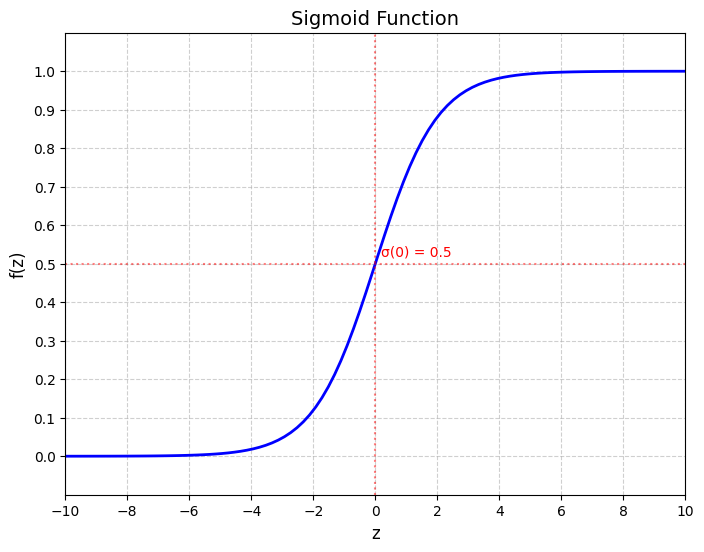

In [ ]:
# Plot of Sigmoid Function
import numpy as np
import matplotlib.pyplot as plt

# Define the sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Generate values from -10 to 10
x = np.linspace(-10, 10, 100)
y = sigmoid(x)

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(x, y, color='blue', linewidth=2)

# Add labels and title
plt.title('Sigmoid Function', fontsize=14)
plt.xlabel('z', fontsize=12)
plt.ylabel('f(z)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Customize axes limits and ticks
plt.xlim(-10, 10)
plt.xticks(np.arange(-10, 11, 2))
plt.ylim(-0.1, 1.1)
plt.yticks(np.arange(0, 1.1, 0.1))

# Highlight key properties
plt.axhline(y=0.5, color='red', linestyle=':', alpha=0.5)
plt.axvline(x=0, color='red', linestyle=':', alpha=0.5)
plt.text(0.2, 0.52, 'f(0) = 0.5', color='red', fontsize=10)

# Display the plot
plt.show()

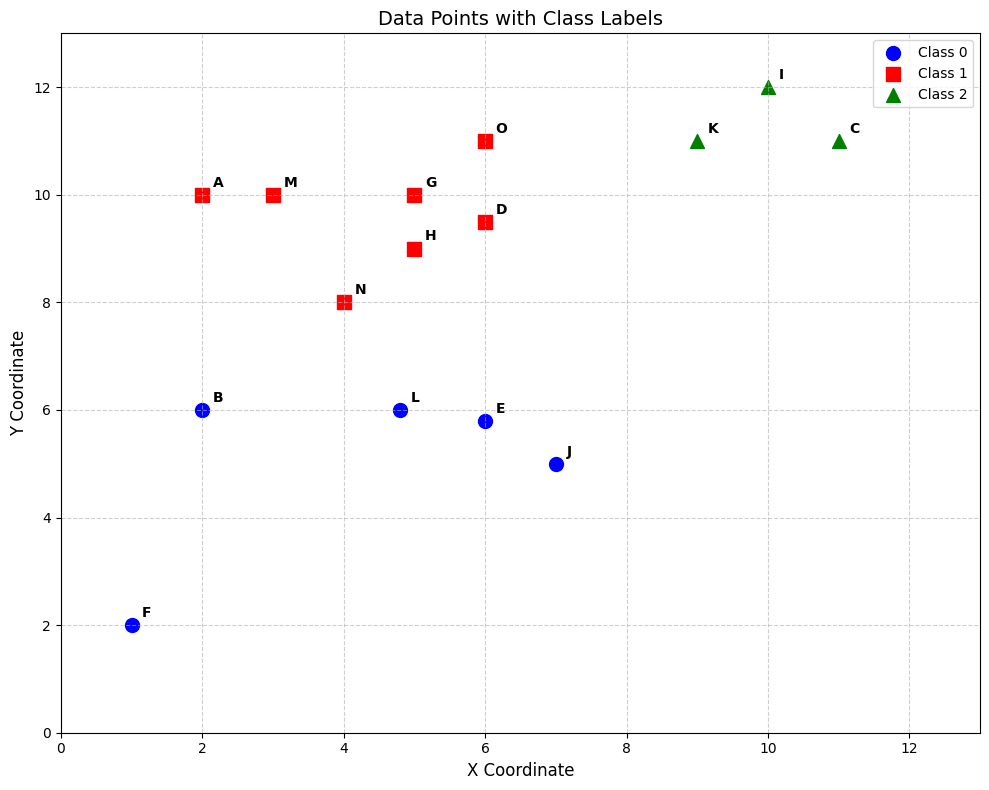

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data points and labels
points = np.array([
    [2,10],  # A
    [2, 6],  # B
    [11,11], # C
    [6, 9.5],  # D
    [6, 5.8],  # E
    [1, 2],  # F
    [5, 10], # G
    [5, 9],  # H
    [10, 12],# I
    [7, 5],  # J
    [9, 11], # K
    [4.8, 6],  # L
    [3,10],  # M
    [4,8],   # N
    [6,11]   # O
])

labels = np.array([1, 0, 2, 1, 0, 0, 1, 1, 2, 0, 2, 0, 1, 1, 1])

# Create figure
plt.figure(figsize=(10, 8))

# Define colors and markers for each class
class_settings = {
    0: {'color': 'blue', 'marker': 'o', 'label': 'Class 0'},
    1: {'color': 'red', 'marker': 's', 'label': 'Class 1'},
    2: {'color': 'green', 'marker': '^', 'label': 'Class 2'}
}

# Plot each class separately
for class_id in np.unique(labels):
    class_points = points[labels == class_id]
    plt.scatter(
        class_points[:, 0],
        class_points[:, 1],
        c=class_settings[class_id]['color'],
        marker=class_settings[class_id]['marker'],
        s=100,
        label=class_settings[class_id]['label']
    )

# Add point labels (A, B, C, ...)
for i, (x, y) in enumerate(points):
    plt.text(x + 0.15, y + 0.15, chr(65 + i), fontsize=10, fontweight='bold')

# Customize plot
plt.title('Data Points with Class Labels', fontsize=14)
plt.xlabel('X Coordinate', fontsize=12)
plt.ylabel('Y Coordinate', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

# Set axis limits with some padding
plt.xlim(0, 13)
plt.ylim(0, 13)

# Show plot
plt.tight_layout()
plt.show()

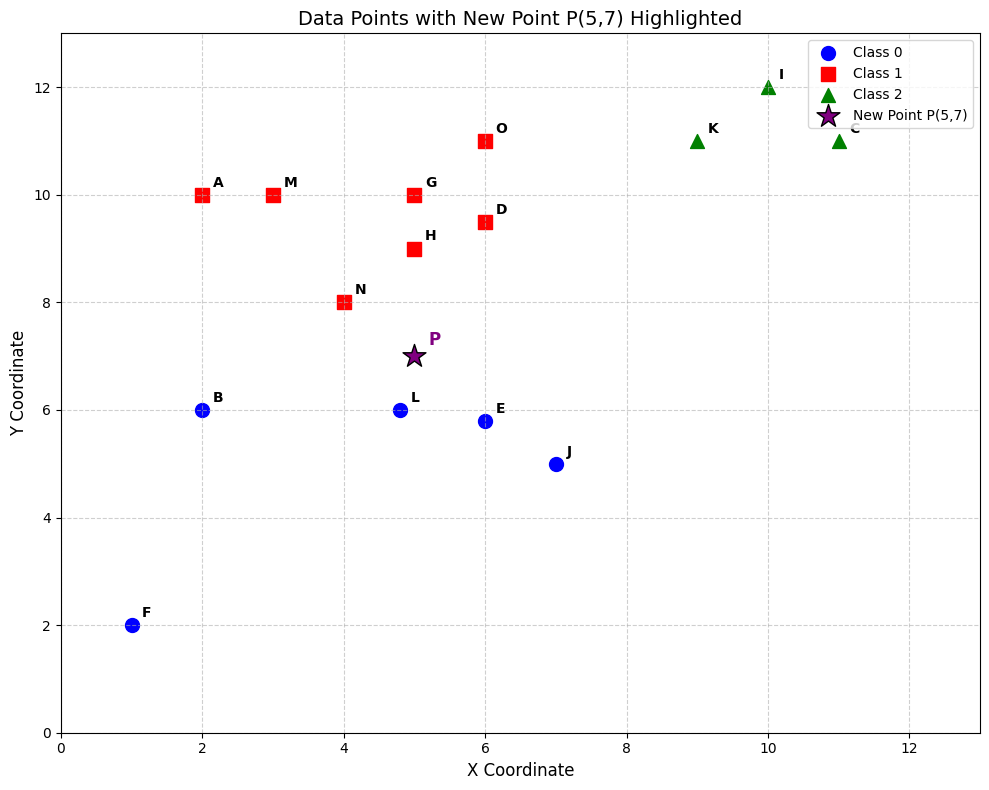

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Original data points and labels
points = np.array([
    [2,10],  # A
    [2, 6],  # B
    [11,11], # C
    [6, 9.5],  # D
    [6, 5.8],  # E
    [1, 2],  # F
    [5, 10], # G
    [5, 9],  # H
    [10, 12],# I
    [7, 5],  # J
    [9, 11], # K
    [4.8, 6],  # L
    [3,10],  # M
    [4,8],   # N
    [6,11]   # O
])

labels = np.array([1, 0, 2, 1, 0, 0, 1, 1, 2, 0, 2, 0, 1, 1, 1])

# New point to highlight
P = np.array([5, 7])

# Create figure
plt.figure(figsize=(10, 8))

# Define colors and markers for each class
class_settings = {
    0: {'color': 'blue', 'marker': 'o', 'label': 'Class 0'},
    1: {'color': 'red', 'marker': 's', 'label': 'Class 1'},
    2: {'color': 'green', 'marker': '^', 'label': 'Class 2'}
}

# Plot each class separately
for class_id in np.unique(labels):
    class_points = points[labels == class_id]
    plt.scatter(
        class_points[:, 0],
        class_points[:, 1],
        c=class_settings[class_id]['color'],
        marker=class_settings[class_id]['marker'],
        s=100,
        label=class_settings[class_id]['label']
    )

# Plot the new point P
plt.scatter(
    P[0], P[1],
    c='purple',
    marker='*',
    s=300,
    label='New Point P(5,7)',
    edgecolors='black',
    linewidths=1
)

# Add point labels (A-O for original points)
for i, (x, y) in enumerate(points):
    plt.text(x + 0.15, y + 0.15, chr(65 + i), fontsize=10, fontweight='bold')

# Label point P
plt.text(P[0] + 0.2, P[1] + 0.2, 'P', fontsize=12, fontweight='bold', color='purple')

# Customize plot
plt.title('Data Points with New Point P(5,7) Highlighted', fontsize=14)
plt.xlabel('X Coordinate', fontsize=12)
plt.ylabel('Y Coordinate', fontsize=12)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# Set axis limits with some padding
plt.xlim(0, 13)
plt.ylim(0, 13)

# Show plot
plt.tight_layout()
plt.show()

Distance from P(5,7) to all points:
----------------------------------------
Distance to L[4.8 6. ] (Class 0): 1.020
Distance to N[4. 8.] (Class 1): 1.414
Distance to E[6.  5.8] (Class 0): 1.562
Distance to H[5. 9.] (Class 1): 2.000
Distance to D[6.  9.5] (Class 1): 2.693
Distance to J[7. 5.] (Class 0): 2.828
Distance to G[ 5. 10.] (Class 1): 3.000
Distance to B[2. 6.] (Class 0): 3.162
Distance to M[ 3. 10.] (Class 1): 3.606
Distance to O[ 6. 11.] (Class 1): 4.123
Distance to A[ 2. 10.] (Class 1): 4.243
Distance to K[ 9. 11.] (Class 2): 5.657
Distance to F[1. 2.] (Class 0): 6.403
Distance to I[10. 12.] (Class 2): 7.071
Distance to C[11. 11.] (Class 2): 7.211

3 Nearest Neighbors (k=3):
----------------------------------------
L[4.8 6. ] (Class 0): 1.020
N[4. 8.] (Class 1): 1.414
E[6.  5.8] (Class 0): 1.562


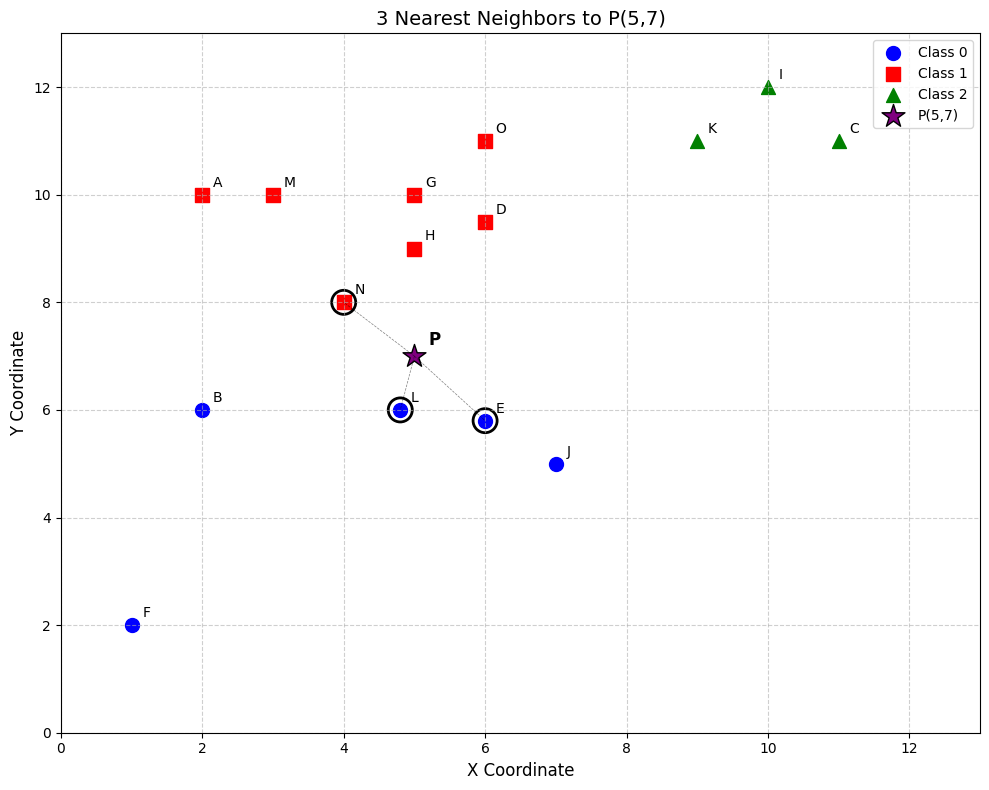

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

# Original data points and labels
points = np.array([
    [2,10],  # A
    [2, 6],  # B
    [11,11], # C
    [6, 9.5],  # D
    [6, 5.8],  # E
    [1, 2],  # F
    [5, 10], # G
    [5, 9],  # H
    [10, 12],# I
    [7, 5],  # J
    [9, 11], # K
    [4.8, 6],  # L
    [3,10],  # M
    [4,8],   # N
    [6,11]   # O
])
labels = np.array([1, 0, 2, 1, 0, 0, 1, 1, 2, 0, 2, 0, 1, 1, 1])
point_names = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O']

# New point and k value
P = np.array([5, 7])
k = 3

# Function to calculate Euclidean distance
def euclidean_distance(p1, p2):
    return sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

# Calculate distances from P to all points
distances = []
for i, point in enumerate(points):
    dist = euclidean_distance(P, point)
    distances.append((dist, point_names[i], labels[i], point))

# Sort distances and get k nearest neighbors
distances.sort()
k_nearest = distances[:k]

# Print all distances
print("Distance from P(5,7) to all points:")
print("-" * 40)
for dist, name, label, point in distances:
    print(f"Distance to {name}{point} (Class {label}): {dist:.3f}")

# Print k nearest neighbors
print("\n3 Nearest Neighbors (k=3):")
print("-" * 40)
for dist, name, label, point in k_nearest:
    print(f"{name}{point} (Class {label}): {dist:.3f}")

# Visualization
plt.figure(figsize=(10, 8))

# Plot each class
class_settings = {
    0: {'color': 'blue', 'marker': 'o', 'label': 'Class 0'},
    1: {'color': 'red', 'marker': 's', 'label': 'Class 1'},
    2: {'color': 'green', 'marker': '^', 'label': 'Class 2'}
}

for class_id in np.unique(labels):
    class_mask = (labels == class_id)
    plt.scatter(points[class_mask, 0], points[class_mask, 1],
               c=class_settings[class_id]['color'],
               marker=class_settings[class_id]['marker'],
               s=100,
               label=class_settings[class_id]['label'])

# Plot point P
plt.scatter(P[0], P[1], c='purple', marker='*', s=300,
           label='P(5,7)', edgecolors='black')

# Highlight nearest neighbors
for dist, name, label, point in k_nearest:
    plt.scatter(point[0], point[1], facecolors='none',
               edgecolors='black', s=300, linewidths=2)
    # Draw line between P and neighbor
    plt.plot([P[0], point[0]], [P[1], point[1]],
            'k--', linewidth=0.5, alpha=0.5)

# Add labels
for i, (x, y) in enumerate(points):
    plt.text(x + 0.15, y + 0.15, point_names[i], fontsize=10)
plt.text(P[0] + 0.2, P[1] + 0.2, 'P', fontsize=12, fontweight='bold')

# Customize plot
plt.title(f'3 Nearest Neighbors to P(5,7)', fontsize=14)
plt.xlabel('X Coordinate', fontsize=12)
plt.ylabel('Y Coordinate', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0, 13)
plt.ylim(0, 13)

plt.tight_layout()
plt.show()

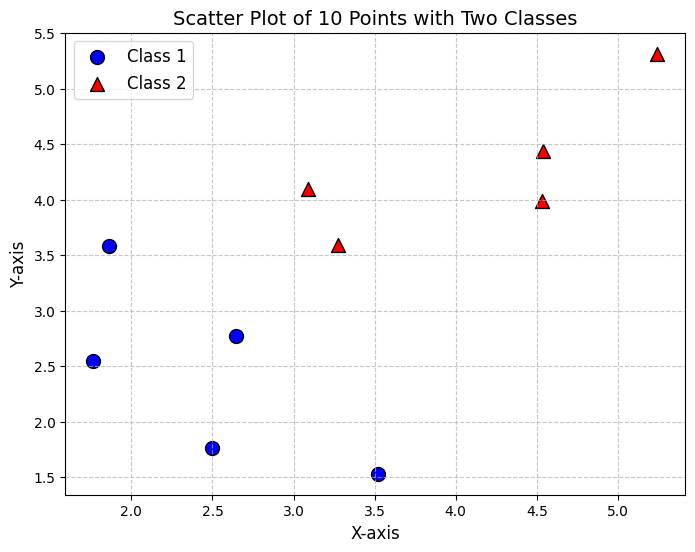

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Generate 10 random points (5 for each class)
class1_x = np.random.normal(2, 1, 5)  # Class 1 x-coordinates
class1_y = np.random.normal(2, 1, 5)  # Class 1 y-coordinates

class2_x = np.random.normal(5, 1, 5)  # Class 2 x-coordinates
class2_y = np.random.normal(5, 1, 5)  # Class 2 y-coordinates

# Create the plot
plt.figure(figsize=(8, 6))

# Plot class 1 points (blue circles)
plt.scatter(class1_x, class1_y, c='blue', label='Class 1', s=100, edgecolors='black')

# Plot class 2 points (red triangles)
plt.scatter(class2_x, class2_y, c='red', marker='^', label='Class 2', s=100, edgecolors='black')

# Add labels and title
plt.title('Scatter Plot of 10 Points with Two Classes', fontsize=14)
plt.xlabel('X-axis', fontsize=12)
plt.ylabel('Y-axis', fontsize=12)
plt.legend(fontsize=12)

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.show()

Checking Boundary 1:
VIOLATION: Point (1.0,1.0) above boundary y=-0.20
VIOLATION: Point (1.2,0.8) above boundary y=0.56
VIOLATION: Point (0.8,0.9) above boundary y=-0.96
VIOLATION: Point (1.1,1.1) above boundary y=0.18
VIOLATION: Point (0.9,0.8) above boundary y=-0.58
VIOLATION: Point (2.5,2.5) below boundary y=5.50
VIOLATION: Point (2.7,2.3) below boundary y=6.26
VIOLATION: Point (2.3,2.4) below boundary y=4.74
VIOLATION: Point (2.6,2.6) below boundary y=5.88
VIOLATION: Point (2.4,2.2) below boundary y=5.12

Checking Boundary 2:
VIOLATION: Point (1.0,1.0) above boundary y=-0.50
VIOLATION: Point (1.2,0.8) above boundary y=0.20
VIOLATION: Point (0.8,0.9) above boundary y=-1.20
VIOLATION: Point (1.1,1.1) above boundary y=-0.15
VIOLATION: Point (0.9,0.8) above boundary y=-0.85
VIOLATION: Point (2.5,2.5) below boundary y=4.75
VIOLATION: Point (2.7,2.3) below boundary y=5.45
VIOLATION: Point (2.3,2.4) below boundary y=4.05
VIOLATION: Point (2.6,2.6) below boundary y=5.10
VIOLATION: Point (2

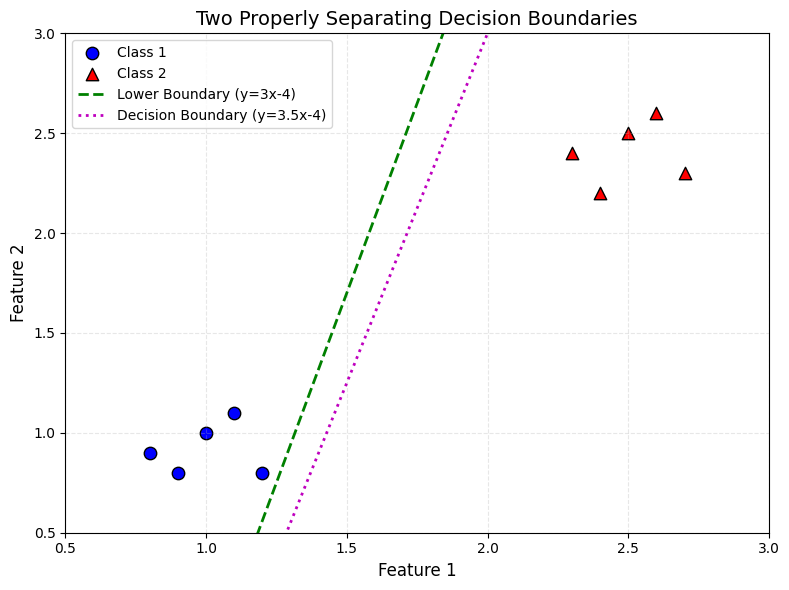

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Set up clearly separable data points
class1 = np.array([[1, 1], [1.2, 0.8], [0.8, 0.9], [1.1, 1.1], [0.9, 0.8]])  # All y < 1.2
class2 = np.array([[2.5, 2.5], [2.7, 2.3], [2.3, 2.4], [2.6, 2.6], [2.4, 2.2]])  # All y > 2.2

# Define two boundaries that definitely separate the classes
def boundary1(x): return 3.8*x - 4 # Lower boundary (all class1 below)
def boundary2(x): return 3.5*x - 4  # Upper boundary (all class2 above)

# Verify complete separation
def check_separation(boundary, class_below, class_above):
    for x, y in class_below:
        if y >= boundary(x):
            print(f"VIOLATION: Point ({x},{y}) above boundary y={boundary(x):.2f}")
    for x, y in class_above:
        if y <= boundary(x):
            print(f"VIOLATION: Point ({x},{y}) below boundary y={boundary(x):.2f}")

print("Checking Boundary 1:")
check_separation(boundary1, class1, class2)
print("\nChecking Boundary 2:")
check_separation(boundary2, class1, class2)

# Create plot
plt.figure(figsize=(8, 6))

# Plot data points
plt.scatter(class1[:,0], class1[:,1], c='blue', s=80, edgecolor='black', label='Class 1')
plt.scatter(class2[:,0], class2[:,1], c='red', marker='^', s=80, edgecolor='black', label='Class 2')

# Plot decision boundaries
x_vals = np.linspace(0.5, 3, 100)
plt.plot(x_vals, boundary1(x_vals), 'g--', linewidth=2, label='Lower Boundary (y=3x-4)')
plt.plot(x_vals, boundary2(x_vals), 'm:', linewidth=2, label='Decision Boundary (y=3.5x-4)')

# Shade the separation region
#plt.fill_between(x_vals, boundary1(x_vals), boundary2(x_vals), color='gray', alpha=0.1)

# Customize plot
plt.title('Two Properly Separating Decision Boundaries', fontsize=14)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.xlim(0.5, 3)
plt.ylim(0.5, 3)

plt.tight_layout()
plt.show()

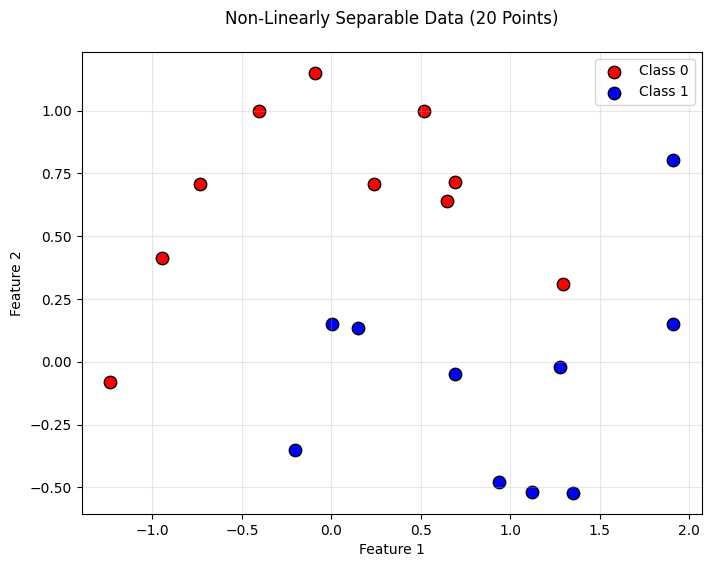

Generated Data Points (X) and Labels (y):
[[ 1.29247562e+00  3.07742994e-01  0.00000000e+00]
 [ 1.27822328e+00 -2.20993647e-02  1.00000000e+00]
 [ 1.12343938e+00 -5.17581176e-01  1.00000000e+00]
 [ 6.44426682e-01  6.39416335e-01  0.00000000e+00]
 [-9.44583656e-01  4.13130407e-01  0.00000000e+00]
 [-9.02459557e-02  1.15130012e+00  0.00000000e+00]
 [ 1.62754994e-03  1.52012143e-01  1.00000000e+00]
 [ 5.19025157e-01  9.98956272e-01  0.00000000e+00]
 [ 1.91164892e+00  1.51341177e-01  1.00000000e+00]
 [ 1.35018470e+00 -5.21701805e-01  1.00000000e+00]
 [ 6.89768572e-01 -4.98552866e-02  1.00000000e+00]
 [ 6.92410255e-01  7.17900536e-01  0.00000000e+00]
 [-1.23863165e+00 -8.18103803e-02  0.00000000e+00]
 [ 1.91065171e+00  8.04848327e-01  1.00000000e+00]
 [ 2.38248137e-01  7.06124365e-01  0.00000000e+00]
 [-2.01711292e-01 -3.51566891e-01  1.00000000e+00]
 [-7.31505702e-01  7.07627363e-01  0.00000000e+00]
 [ 1.49171908e-01  1.32683352e-01  1.00000000e+00]
 [ 9.39244670e-01 -4.79707619e-01  1.000

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Generate 20 non-linearly separable points (moons pattern)
np.random.seed(42)
X, y = make_moons(n_samples=20, noise=0.2, random_state=42)

# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', label='Class 0', s=80, edgecolor='k')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Class 1', s=80, edgecolor='k')
plt.title("Non-Linearly Separable Data (20 Points)", pad=20)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print coordinates and labels
print("Generated Data Points (X) and Labels (y):")
print(np.hstack([X, y.reshape(-1, 1)]))

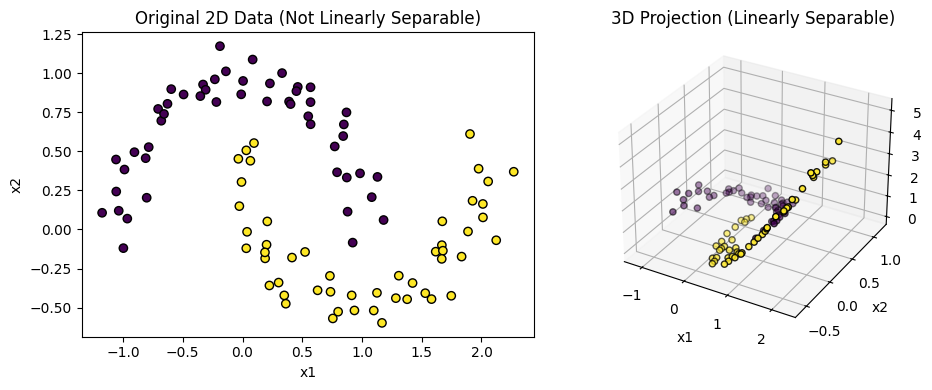

Original 2D data (first 5 points):
[[ 1.58202308 -0.44581483]
 [ 0.0660451   0.4392075 ]
 [ 0.73663111 -0.39896339]
 [-1.05692838  0.2424558 ]
 [-0.80216162  0.20271838]]

Transformed 3D data (first 5 points):
[[ 1.58202308 -0.44581483  2.50279702 -0.70528935  0.19875086]
 [ 0.0660451   0.4392075   0.00436196  0.0290075   0.19290323]
 [ 0.73663111 -0.39896339  0.5426254  -0.29388885  0.15917179]
 [-1.05692838  0.2424558   1.1170976  -0.25625842  0.05878482]
 [-0.80216162  0.20271838  0.64346326 -0.16261291  0.04109474]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures
from mpl_toolkits.mplot3d import Axes3D

# Generate non-linearly separable data
X, y = make_moons(n_samples=100, noise=0.1, random_state=42)

# Plot original 2D data
plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k')
plt.title("Original 2D Data (Not Linearly Separable)")
plt.xlabel("x1")
plt.ylabel("x2")

# Add polynomial features (project to 3D)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Plot in 3D space where data becomes separable
ax = plt.subplot(122, projection='3d')
ax.scatter(X_poly[:, 0], X_poly[:, 1], X_poly[:, 2], c=y, cmap='viridis', edgecolors='k')
ax.set_title("3D Projection (Linearly Separable)")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x1² + x2²")
plt.tight_layout()
plt.show()

# Show the transformation
print("Original 2D data (first 5 points):")
print(X[:5])
print("\nTransformed 3D data (first 5 points):")
print(X_poly[:5])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import interact, FloatSlider

# Generate non-linearly separable data
X, y = make_moons(n_samples=10, noise=0.01, random_state=42)

# Add polynomial features (project to 3D)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Create interactive 3D plot
def plot_3d_view(elev=45, azim=45):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plot original moons in 3D space
    ax.scatter(X_poly[:, 0], X_poly[:, 1], X_poly[:, 2],
               c=y, cmap='viridis', s=50, edgecolor='k', depthshade=True)

    # Add plane to show separability
    xx, yy = np.meshgrid(np.linspace(-1.5, 2.5, 10), np.linspace(-1, 1.5, 10))
    zz = 0.5*xx + 0.5*yy - 0.7  # Example separating plane
    ax.plot_surface(xx, yy, zz, alpha=0.3, color='gray')

    ax.set_title("3D Projection with Polynomial Features\n(Linearly Separable in Higher Dimension)", pad=20)
    ax.set_xlabel("Original x1")
    ax.set_ylabel("Original x2")
    ax.set_zlabel("x1² + x2² + x1x2")
    ax.view_init(elev=elev, azim=azim)
    plt.tight_layout()
    plt.show()

# Create interactive controls
interact(plot_3d_view,
         elev=FloatSlider(min=-90, max=90, step=1, value=45, description='Elevation'),
         azim=FloatSlider(min=0, max=360, step=1, value=45, description='Rotation'))

interactive(children=(FloatSlider(value=45.0, description='Elevation', max=90.0, min=-90.0, step=1.0), FloatSl…

<function __main__.plot_3d_view(elev=45, azim=45)>

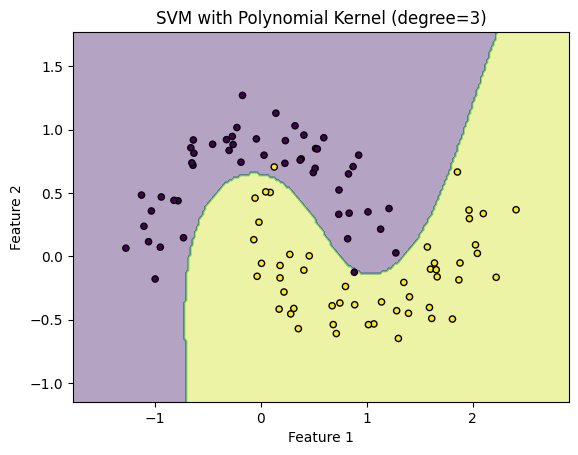

Number of support vectors: 18


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_moons

# Generate a non-linearly separable dataset
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

# Create an SVM classifier with polynomial kernel
poly_kernel_svm = svm.SVC(kernel='poly', degree=3, coef0=1, C=5)
poly_kernel_svm.fit(X, y)

# Create a mesh to plot the decision boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Plot the decision boundary
Z = poly_kernel_svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k')
plt.title("SVM with Polynomial Kernel (degree=3)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Print support vectors
print(f"Number of support vectors: {len(poly_kernel_svm.support_vectors_)}")

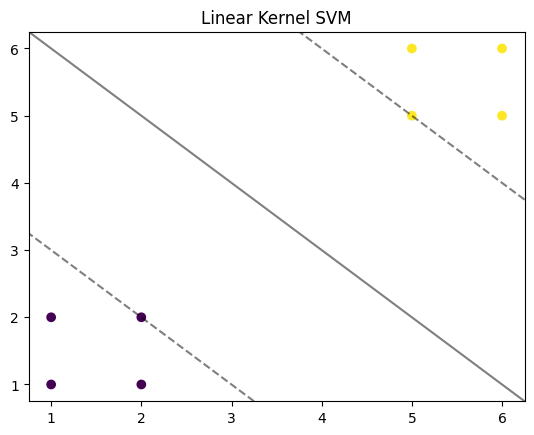

In [ ]:
from sklearn import svm
import numpy as np
import matplotlib.pyplot as plt

# Create simple linearly separable data
X = np.array([[1,1], [2,2], [1,2], [2,1], [5,5], [6,6], [5,6], [6,5]])
y = np.array([0, 0, 0, 0, 1, 1, 1, 1])

# Create and fit linear SVM
linear_svm = svm.SVC(kernel='linear')
linear_svm.fit(X, y)

# Plotting
plt.scatter(X[:,0], X[:,1], c=y)
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create grid to evaluate model
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = linear_svm.decision_function(xy).reshape(XX.shape)

# Plot decision boundary and margins
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1],
           alpha=0.5, linestyles=['--', '-', '--'])
plt.title("Linear Kernel SVM")
plt.show()

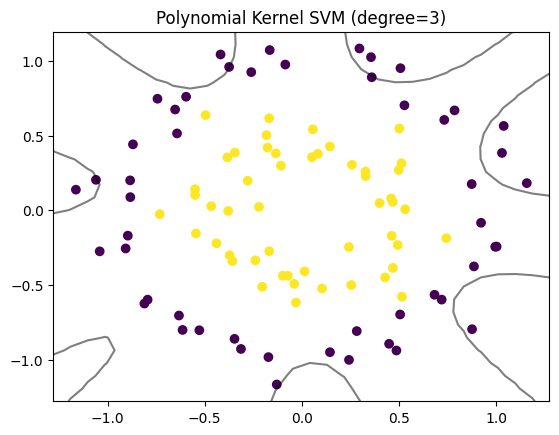

In [ ]:
from sklearn.datasets import make_circles

# Create non-linear data (concentric circles)
X, y = make_circles(n_samples=100, noise=0.1, factor=0.5, random_state=42)

# Create polynomial kernel SVM (degree=3)
poly_svm = svm.SVC(kernel='poly', degree=7, C=1)
poly_svm.fit(X, y)

# Plotting
plt.scatter(X[:,0], X[:,1], c=y)
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create grid
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = poly_svm.decision_function(xy).reshape(XX.shape)

# Plot decision boundary
ax.contour(XX, YY, Z, colors='k', levels=[0], alpha=0.5)
plt.title("Polynomial Kernel SVM (degree=3)")
plt.show()

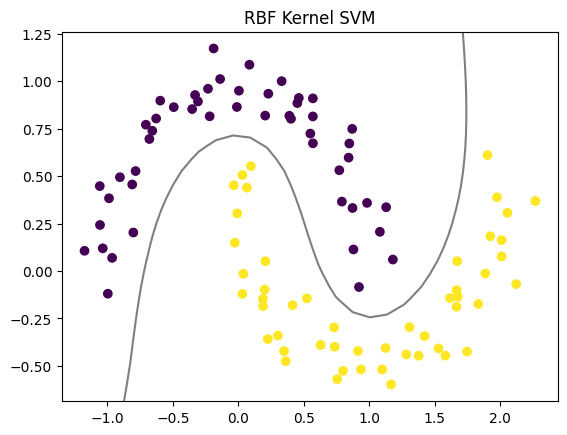

In [ ]:
from sklearn.datasets import make_moons

# Create moon-shaped non-linear data
X, y = make_moons(n_samples=100, noise=0.1, random_state=42)

# Create RBF kernel SVM
rbf_svm = svm.SVC(kernel='rbf', gamma=0.9, C=100)
rbf_svm.fit(X, y)

# Plotting
plt.scatter(X[:,0], X[:,1], c=y)
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create grid
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = rbf_svm.decision_function(xy).reshape(XX.shape)

# Plot decision boundary
ax.contour(XX, YY, Z, colors='k', levels=[0], alpha=0.5)
plt.title("RBF Kernel SVM")
plt.show()

In [ ]:
!pip install tabulate

In [ ]:
import pandas as pd

data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rainy', 'Rainy', 'Rainy', 'Overcast',
                'Sunny', 'Sunny', 'Rainy', 'Sunny', 'Overcast', 'Overcast', 'Rainy'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool',
                   'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal',
                 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Windy': [False, True, False, False, False, True, True,
              False, False, False, True, True, False, True],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes',
                   'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}

# Create DataFrame
df = pd.DataFrame(data)

# Display the table
print(df.to_string(index=False))

 Outlook Temperature Humidity  Windy PlayTennis
   Sunny         Hot     High  False         No
   Sunny         Hot     High   True         No
Overcast         Hot     High  False        Yes
   Rainy        Mild     High  False        Yes
   Rainy        Cool   Normal  False        Yes
   Rainy        Cool   Normal   True         No
Overcast        Cool   Normal   True        Yes
   Sunny        Mild     High  False         No
   Sunny        Cool   Normal  False        Yes
   Rainy        Mild   Normal  False        Yes
   Sunny        Mild   Normal   True        Yes
Overcast        Mild     High   True        Yes
Overcast         Hot   Normal  False        Yes
   Rainy        Mild     High   True         No


Model Accuracy: 0.67

Decision Tree Rules:
|--- Outlook_Overcast <= 0.50
|   |--- Humidity_High <= 0.50
|   |   |--- Outlook_Sunny <= 0.50
|   |   |   |--- class: No
|   |   |--- Outlook_Sunny >  0.50
|   |   |   |--- class: Yes
|   |--- Humidity_High >  0.50
|   |   |--- Outlook_Sunny <= 0.50
|   |   |   |--- class: No
|   |   |--- Outlook_Sunny >  0.50
|   |   |   |--- class: No
|--- Outlook_Overcast >  0.50
|   |--- class: Yes



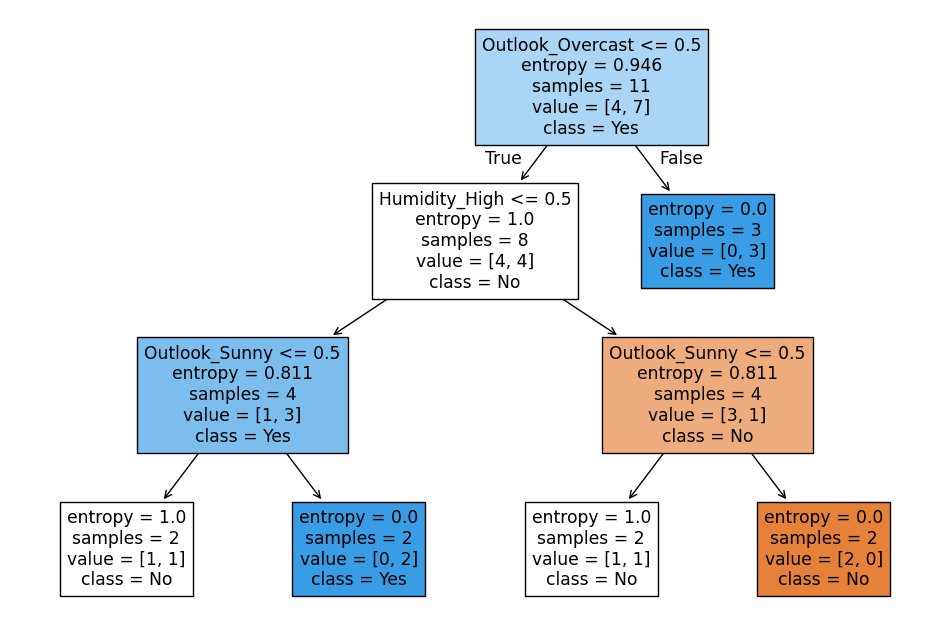


Sample Prediction (Sunny, Hot, High, Windy): No


In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Sample dataset: Predicting whether to play tennis based on weather conditions
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rainy', 'Rainy', 'Rainy', 'Overcast',
                'Sunny', 'Sunny', 'Rainy', 'Sunny', 'Overcast', 'Overcast', 'Rainy'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool',
                   'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal',
                 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Windy': [False, True, False, False, False, True, True,
              False, False, False, True, True, False, True],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes',
                   'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Convert categorical variables to numerical using one-hot encoding
df_encoded = pd.get_dummies(df.drop('PlayTennis', axis=1))

# Store the feature names in the order they were during training
feature_names = df_encoded.columns.tolist()

# Prepare features and target
X = df_encoded
y = df['PlayTennis']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the decision tree classifier
tree = DecisionTreeClassifier(criterion='entropy', max_depth=3)
tree.fit(X_train, y_train)

# Make predictions
y_pred = tree.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

# Display the decision tree rules
tree_rules = export_text(tree, feature_names=feature_names)
print("\nDecision Tree Rules:")
print(tree_rules)

# Visualize the decision tree
plt.figure(figsize=(12,8))
plot_tree(tree, feature_names=feature_names, class_names=['No', 'Yes'], filled=True)
plt.show()

# Example prediction - create new sample with features in correct order
sample_data = {
    'Outlook_Overcast': 0,
    'Outlook_Rainy': 0,
    'Outlook_Sunny': 1,
    'Temperature_Cool': 0,
    'Temperature_Hot': 1,
    'Temperature_Mild': 0,
    'Humidity_High': 1,
    'Humidity_Normal': 0,
    'Windy': 1
}

# Create DataFrame ensuring correct feature order
sample_df = pd.DataFrame([sample_data], columns=feature_names)

prediction = tree.predict(sample_df)
print(f"\nSample Prediction (Sunny, Hot, High, Windy): {prediction[0]}")

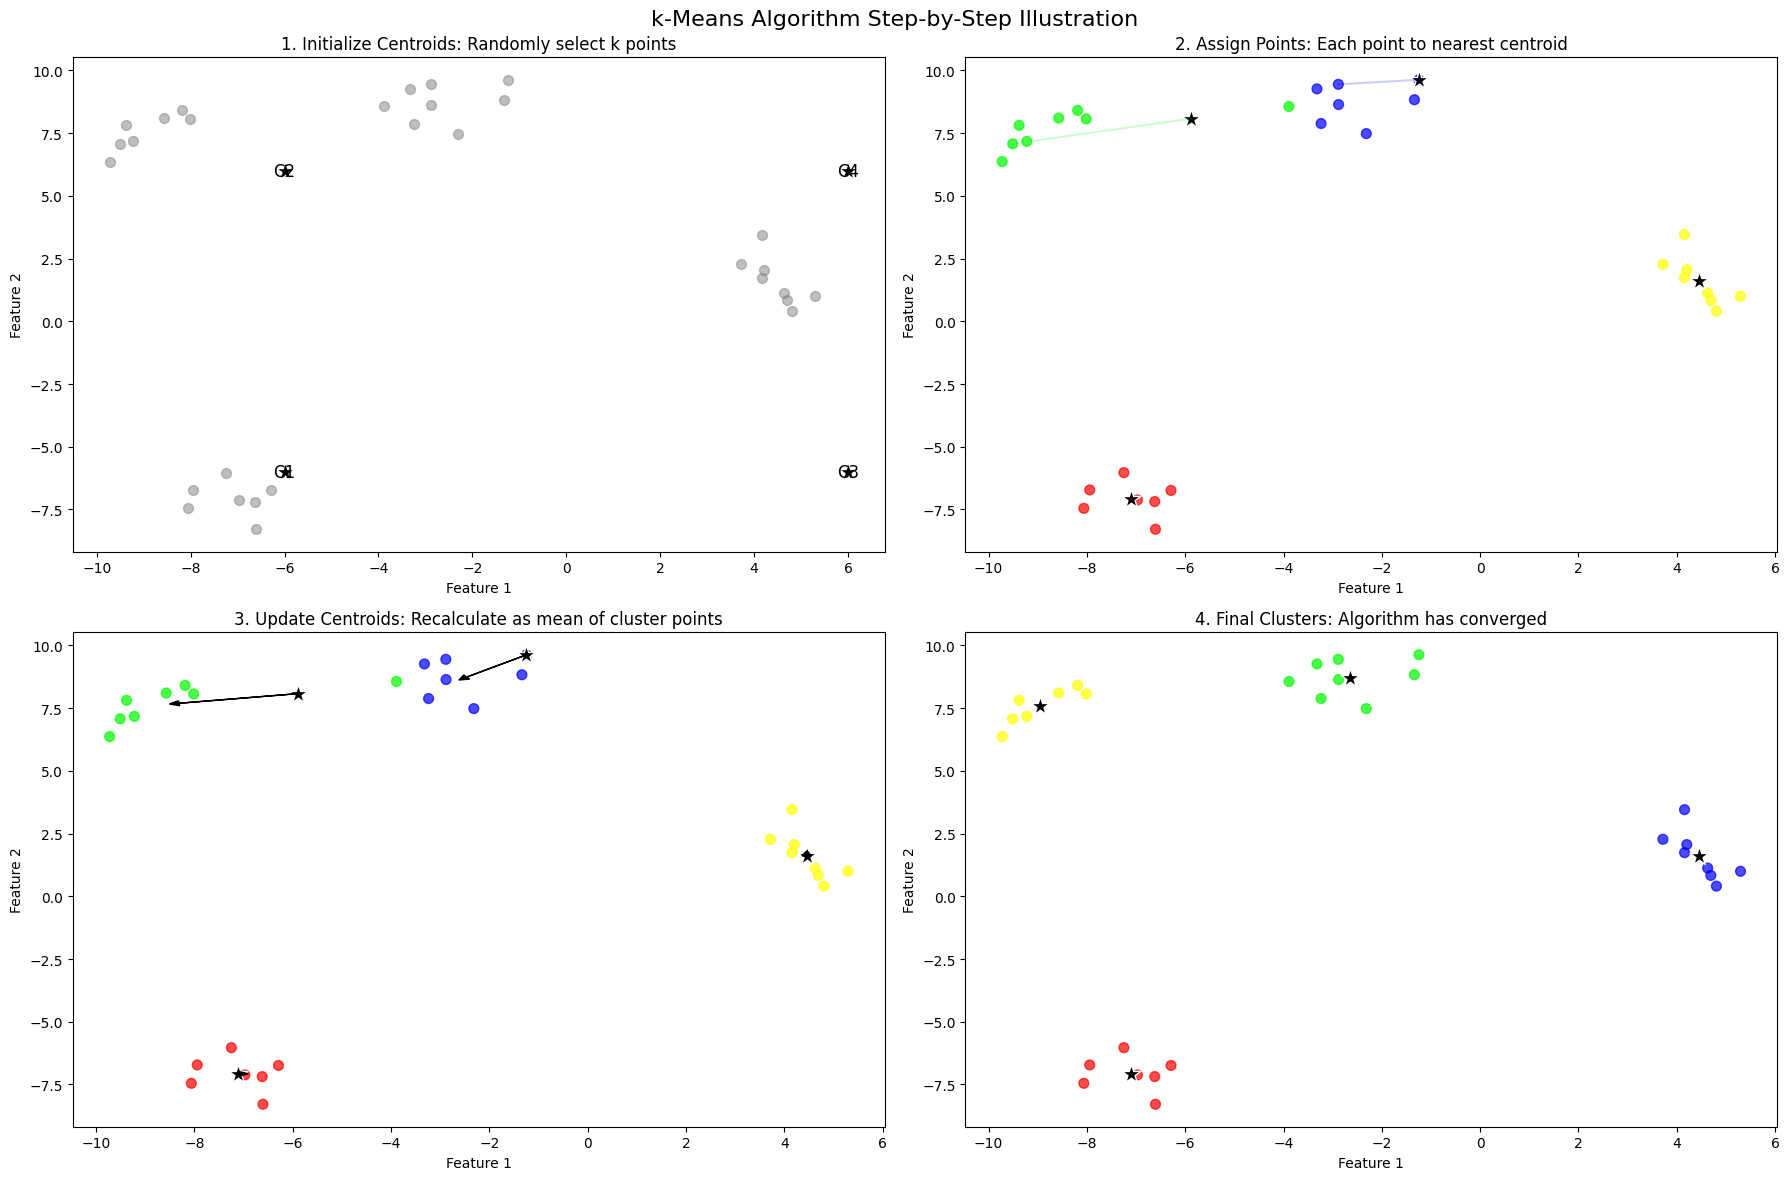

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap

# Set up the figure and subplots
plt.figure(figsize=(18, 12))
plt.suptitle("k-Means Algorithm Step-by-Step Illustration", fontsize=16, y=0.98)

# Generate sample data
np.random.seed(42)
X, y = make_blobs(n_samples=30, centers=4, cluster_std=0.8, random_state=42)

# Custom colormap
cmap = ListedColormap(['#FF0000', '#00FF00', '#0000FF', '#FFFF00'])

# Step 1: Initialize Centroids
plt.subplot(2, 2, 1)
plt.scatter(X[:, 0], X[:, 1], s=50, color='gray', alpha=0.5)
plt.title("1. Initialize Centroids: Randomly select k points")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Manually select initial centroids (for reproducibility)
initial_centroids = np.array([[-6, -6], [-6, 6], [6, -6], [6, 6]])

# Plot initial centroids
plt.scatter(initial_centroids[:, 0], initial_centroids[:, 1],
            s=200, marker='*', c='black', edgecolor='white', linewidth=1)
for i, center in enumerate(initial_centroids):
    plt.text(center[0], center[1], f'C{i+1}', fontsize=12, ha='center', va='center')

# Step 2: Assign Points to Clusters (first iteration)
plt.subplot(2, 2, 2)
kmeans = KMeans(n_clusters=4, init=initial_centroids, n_init=1, max_iter=1)
kmeans.fit(X)
labels = kmeans.labels_

# Plot clusters with assigned colors
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap=cmap, alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, marker='*', c='black', edgecolor='white', linewidth=1)
plt.title("2. Assign Points: Each point to nearest centroid")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Draw lines from points to centroids (for a subset of points)
for i in range(0, len(X), 10):  # plot every 10th point for clarity
    plt.plot([X[i, 0], kmeans.cluster_centers_[labels[i], 0]],
             [X[i, 1], kmeans.cluster_centers_[labels[i], 1]],
             color=cmap(labels[i]), alpha=0.2)

# Step 3: Update Centroids (first iteration)
plt.subplot(2, 2, 3)
new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(4)])

plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap=cmap, alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, marker='*', c='black', edgecolor='white', linewidth=1)

# Show movement of centroids
for i in range(4):
    plt.arrow(kmeans.cluster_centers_[i, 0], kmeans.cluster_centers_[i, 1],
              new_centroids[i, 0] - kmeans.cluster_centers_[i, 0],
              new_centroids[i, 1] - kmeans.cluster_centers_[i, 1],
              head_width=0.2, head_length=0.2, fc='black', ec='black')

plt.title("3. Update Centroids: Recalculate as mean of cluster points")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Step 4: Final Clusters (after convergence)
plt.subplot(2, 2, 4)
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
kmeans.fit(X)
labels = kmeans.labels_

plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap=cmap, alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, marker='*', c='black', edgecolor='white', linewidth=1)
plt.title("4. Final Clusters: Algorithm has converged")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()

Step 1: Initialize Clusters
Each of the 5 points is its own cluster


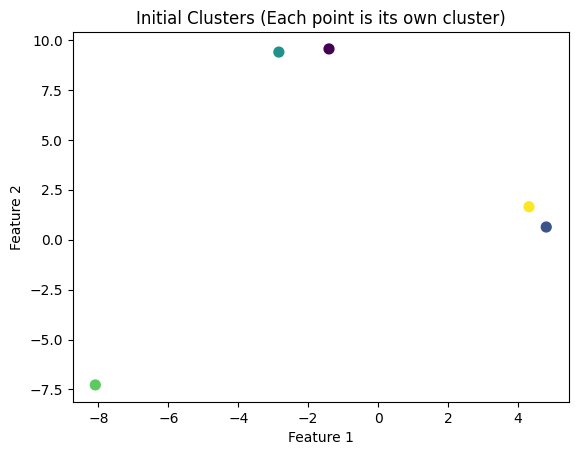


Step 2: Initial Proximity Matrix (Euclidean distances):
[[ 0.   10.87  1.44 18.1   9.76]
 [10.87  0.   11.63 15.13  1.13]
 [ 1.44 11.63  0.   17.47 10.54]
 [18.1  15.13 17.47  0.   15.28]
 [ 9.76  1.13 10.54 15.28  0.  ]]

Demonstrating single linkage method:


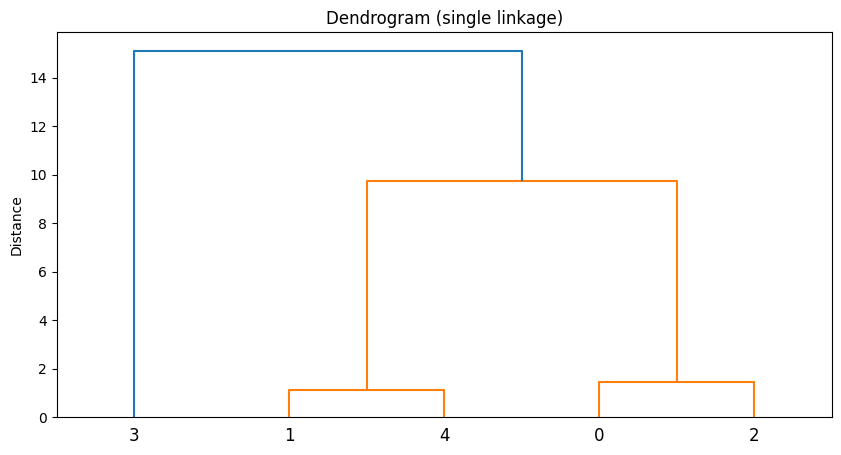


Cluster merging steps:
Step 3: Merge clusters 1 and 4 into new cluster 5 (distance: 1.13)
Step 4: Merge clusters 0 and 2 into new cluster 6 (distance: 1.44)
Step 5: Merge clusters 5 and 6 into new cluster 7 (distance: 9.76)
Step 6: Merge clusters 3 and 7 into new cluster 8 (distance: 15.13)

Demonstrating complete linkage method:


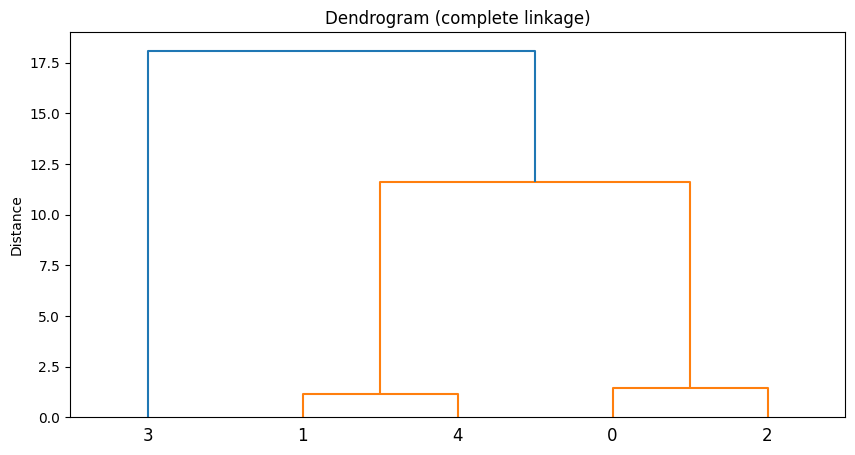


Cluster merging steps:
Step 3: Merge clusters 1 and 4 into new cluster 5 (distance: 1.13)
Step 4: Merge clusters 0 and 2 into new cluster 6 (distance: 1.44)
Step 5: Merge clusters 5 and 6 into new cluster 7 (distance: 11.63)
Step 6: Merge clusters 3 and 7 into new cluster 8 (distance: 18.10)

Demonstrating average linkage method:


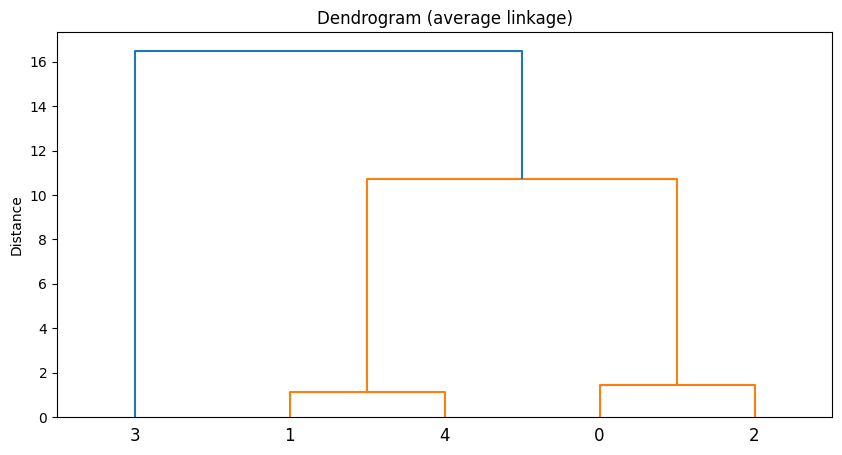


Cluster merging steps:
Step 3: Merge clusters 1 and 4 into new cluster 5 (distance: 1.13)
Step 4: Merge clusters 0 and 2 into new cluster 6 (distance: 1.44)
Step 5: Merge clusters 5 and 6 into new cluster 7 (distance: 10.70)
Step 6: Merge clusters 3 and 7 into new cluster 8 (distance: 16.50)


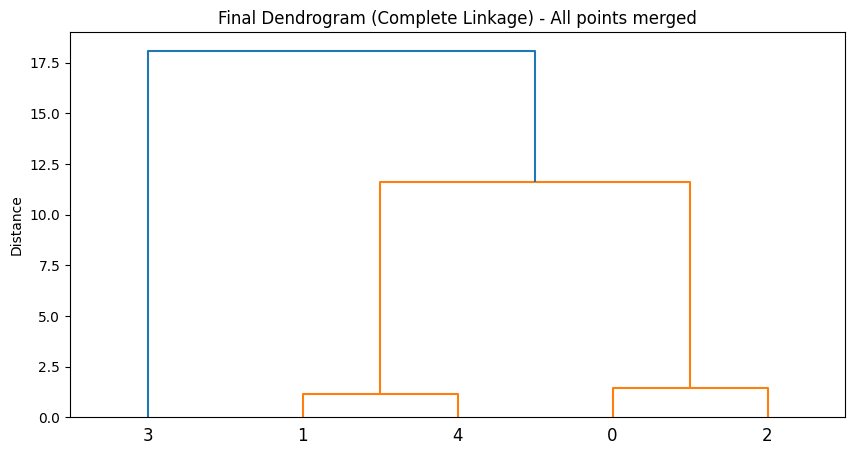

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
from sklearn.datasets import make_blobs

def plot_clusters(X, labels, title):
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

def print_proximity_matrix(matrix, title):
    print(f"\n{title}:")
    print(np.round(matrix, 2))

def main():
    # Create sample data
    np.random.seed(42)
    X, y = make_blobs(n_samples=5, centers=3, cluster_std=0.7, random_state=42)
    X = X[:5]  # Use just 5 points for easier demonstration

    # Step 1: Initialize Clusters - each point is its own cluster
    initial_labels = np.arange(len(X))
    print("Step 1: Initialize Clusters")
    print(f"Each of the {len(X)} points is its own cluster")
    plot_clusters(X, initial_labels, "Initial Clusters (Each point is its own cluster)")

    # Step 2: Compute Proximity Matrix
    proximity_matrix = squareform(pdist(X, 'euclidean'))
    print_proximity_matrix(proximity_matrix, "Step 2: Initial Proximity Matrix (Euclidean distances)")

    # Demonstrate different linkage methods
    methods = ['single', 'complete', 'average']

    for method in methods:
        print(f"\nDemonstrating {method} linkage method:")

        # Perform hierarchical clustering
        Z = linkage(X, method=method)

        # Plot dendrogram
        plt.figure(figsize=(10, 5))
        dendrogram(Z)
        plt.title(f'Dendrogram ({method} linkage)')
        plt.ylabel('Distance')
        plt.show()

        # Print merging steps
        print("\nCluster merging steps:")
        for i, merge in enumerate(Z):
            cluster1 = int(merge[0])
            cluster2 = int(merge[1])
            distance = merge[2]
            new_cluster = len(X) + i
            print(f"Step {i+3}: Merge clusters {cluster1} and {cluster2} "
                  f"into new cluster {new_cluster} (distance: {distance:.2f})")

    # Final dendrogram with all points merged
    Z = linkage(X, method='complete')
    plt.figure(figsize=(10, 5))
    dendrogram(Z)
    plt.title('Final Dendrogram (Complete Linkage) - All points merged')
    plt.ylabel('Distance')
    plt.show()

if __name__ == "__main__":
    main()